# Uncertainty quantification for boiling sim, a nutrient-retention framework during boiling

Parametric uncertainty analysis for beta-carotene retention during household boiling.

**Description**

This notebook recovers the thermal-dose history of a completed simulation from that run's output, and re-evaluates retention under different
kinetic parameters without re-running the simulation. This is possible because, the coupling in the framework is one-directional, that is, the nutrient concentration does not influences the temperature field and therefore  the temperature history is unchanged by any value of the nutrient parameters.

**Contents**

0. Data upload
1. Parameters and constants
2. Load and clean the time series
3. Recover the thermal dose
4. Effective temperature of the food
5. Re-integration and validation
6. One-at-a-time sensitivity
7. Monte Carlo
8. Sobol variance attribution
9. Published parameter pairs
10. Export

**Input required.** `Results - 20min cold start.csv`, contains the reference run
(stainless steel 304, Q = 60 kW/m2, cold start, 20 min), with columns `t`,
`avg_water_temp`, `retentained`, `degraded`, `leached`.


## 0. Upload the data

In Colab, run the cell and choose the CSV. Outside Colab, set `CSV_PATH` by hand.

In [13]:
import os

CSV_PATH = "Results - 20min cold start.csv"   # edit if running locally

try:
    from google.colab import files          # noqa
    if not os.path.exists(CSV_PATH):
        up = files.upload()
        CSV_PATH = list(up.keys())[0]
    IN_COLAB = True
except Exception:
    IN_COLAB = False

print("using:", CSV_PATH, "| exists:", os.path.exists(CSV_PATH))

using: Results - 20min cold start.csv | exists: True


## 1. Parameters and constants

The values are in Table 3 of the manuscript. `K_SAT` is the rate constant at the saturation temperature computed from A and Ea.

In [14]:
import numpy as np, pandas as pd, math
import matplotlib.pyplot as plt

R_GAS = 8.314          # J/mol/K
T_SAT = 373.15         # K, saturation temperature at 1 atm
A_REF = 2.63e6         # 1/s, Arrhenius pre-exponential factor (Table 3)
EA_REF = 70_000.0      # J/mol, activation energy for degradation (Table 3)

K_SAT = A_REF * math.exp(-EA_REF / (R_GAS * T_SAT))

print(f"k(100 C)  = {K_SAT:.4e} 1/s")
print(f"half-life = {math.log(2)/K_SAT/60:.1f} min at the boil")

k(100 C)  = 4.1763e-04 1/s
half-life = 27.7 min at the boil


## 2. Load and clean the time series

1. Duplicate timestamps are dropped.
2. The final row is dropped because
it is written with values rounded to two decimals, which corrupts the numerical
derivative taken in step 4.

In [15]:
raw = pd.read_csv(CSV_PATH)
print("columns:", list(raw.columns))

d = (raw.drop_duplicates(subset="t")
        .sort_values("t")
        .iloc[:-1]                      # drop the rounded final row
        .reset_index(drop=True))

t = d["t"].values
water = d["avg_water_temp"].values
print(f"\n{len(d)} rows, t = {t.min():.1f} to {t.max():.1f} s, "
      f"mean step {np.diff(t).mean():.3f} s")
d.head()

columns: ['t', 'avg_water_temp', 'n_active_bubbles', 'retentained', 'dissolved', 'degraded', 'precipitated', 'leached']

2388 rows, t = 0.1 to 1199.6 s, mean step 0.503 s


,t,avg_water_temp,n_active_bubbles,retentained,dissolved,degraded,precipitated,leached
0,0.1,20.001038,0,99.999812,0.000176,0.000012,0.0,0.000176
1,0.6,20.006287,0,99.999573,0.000367,0.000060,0.0,0.000367
2,1.2,20.013367,0,99.999504,0.000379,0.000116,0.0,0.000379
3,1.7,20.020233,0,99.999467,0.000380,0.000153,0.0,0.000380
4,2.2,20.028137,0,99.999416,0.000380,0.000204,0.0,0.000380


## 3. Recover the thermal dose

The degradation law is first order. Integrating dC/dt = -k(T) C gives

$$S(t) = \exp(-\theta(t)), \qquad \theta(t) = \int_0^t k(T(t'))\,dt'$$

where S is the fraction surviving degradation and theta is the **thermal dose**, the running total of the rate constant. Running it backwards, theta = -ln(S). We use the `degraded` column of the data.

Dividing theta by k(100 C) converts it into an **equivalent time at boiling**, the number of seconds the food would have had to spend at 100 C to accumulate the same degradation.

In [16]:
S = (100.0 - d["degraded"].values) / 100.0        # surviving fraction
theta = -np.log(np.clip(S, 1e-12, None))          # thermal dose

rows = []
for tt in (600, 900, 1200):
    i = int(np.argmin(abs(t - tt)))
    rows.append(dict(t_s=t[i],
                     retained_pct=d["retentained"].values[i],
                     degraded_pct=d["degraded"].values[i],
                     leached_pct=d["leached"].values[i],
                     theta=theta[i],
                     t_equiv_boil_s=theta[i]/K_SAT,
                     water_C=water[i]))
dose_table = pd.DataFrame(rows)
dose_table.round(4)

,t_s,retained_pct,degraded_pct,leached_pct,theta,t_equiv_boil_s,water_C
0,599.7572,95.2494,4.5767,0.1739,0.0468,112.1724,99.936
1,899.9456,85.8509,13.9142,0.2348,0.1498,358.7509,99.948
2,1199.6085,75.9221,23.8169,0.2610,0.2720,651.3620,99.959


## 4. Effective temperature of the food

Differentiating theta gives the volume-mean rate constant at each instant. Inverting the Arrhenius law turns that into an **effective temperature**, that is, the temperature at which the whole carrot would have to be held to degrade at the observed rate.

t =  119.8 s   T_eff =   0.70 C   water =  42.81 C
t =  299.9 s   T_eff =  58.82 C   water =  74.77 C
t =  420.1 s   T_eff =  81.54 C   water =  99.98 C
t =  600.0 s   T_eff =  93.33 C   water =  99.94 C
t =  749.9 s   T_eff =  97.03 C   water =  99.95 C
t =  900.2 s   T_eff =  98.80 C   water =  99.95 C
t = 1050.0 s   T_eff =  99.62 C   water =  99.94 C


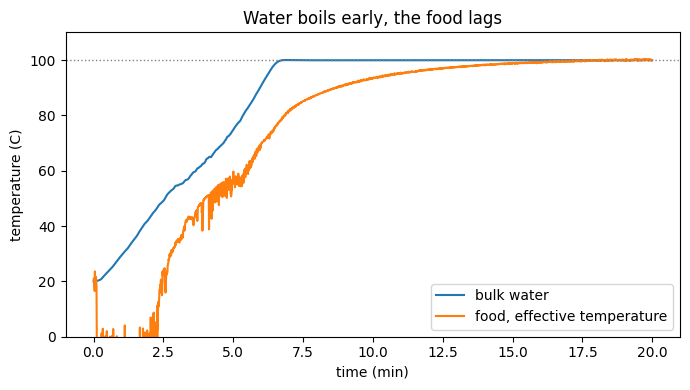

In [17]:
dt = np.diff(t)
t_mid = 0.5 * (t[1:] + t[:-1])
k_bar = np.clip(np.diff(theta) / dt, 1e-14, None)          # volume-mean rate constant

T_eff_K = 1.0 / (1.0/T_SAT - np.log(k_bar/K_SAT) * R_GAS / EA_REF)
T_eff_C = T_eff_K - 273.15
inv_T   = 1.0/T_eff_K - 1.0/T_SAT                          # reused in step 5

for tt in (120, 300, 420, 600, 750, 900, 1050):
    i = int(np.argmin(abs(t_mid - tt))); j = int(np.argmin(abs(t - tt)))
    print(f"t = {t_mid[i]:6.1f} s   T_eff = {T_eff_C[i]:6.2f} C   water = {water[j]:6.2f} C")

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(t/60, water, label="bulk water")
ax.plot(t_mid/60, T_eff_C, label="food, effective temperature")
ax.axhline(100, ls=":", lw=1, color="grey")
ax.set_xlabel("time (min)"); ax.set_ylabel("temperature (C)")
ax.set_ylim(0, 110); ax.legend(); ax.set_title("Water boils early, the food lags")
plt.tight_layout(); plt.show()

## 5. Re-integration and validation

To evaluate a different parameter pair we rebuild the dose from the effective-temperature history, using

$$k(T) = k(T_{sat}) \exp\!\left[-\frac{E_a}{R}\left(\frac{1}{T}-\frac{1}{T_{sat}}\right)\right]$$

which is the Arrhenius law rewritten around the saturation temperature. Writing it this way lets us vary `k_sat` and `Ea` independently (which becomes relevant in step 7).

**Validation is important here.** Feeding the reference parameters back in must return the run's own retention. And it does, to better than 0.01 percentage points, which makes the procedure exact for the degradation pathway.

In [18]:
def retention(k_sat, Ea, upto=900.0, chunk=4000):
    """Retention (%) at time `upto` for given k(T_sat) [1/s] and Ea [J/mol]."""
    m  = t_mid <= upto
    iv, dd = inv_T[m], dt[m]
    k_sat = np.atleast_1d(np.asarray(k_sat, float))
    Ea    = np.atleast_1d(np.asarray(Ea, float))
    out   = np.empty(len(k_sat))
    for a in range(0, len(k_sat), chunk):                  # chunked to bound memory
        b = min(a+chunk, len(k_sat))
        dose = (k_sat[a:b,None] * np.exp(-Ea[a:b,None]/R_GAS * iv[None,:]) * dd[None,:]).sum(axis=1)
        out[a:b] = 100.0 * np.exp(-dose)
    return out

print(f"{'time':>8}  {'re-integrated':>14}  {'run output':>12}  {'difference':>11}")
for tt in (600, 900, 1200):
    i = int(np.argmin(abs(t - tt)))
    a = retention(K_SAT, EA_REF, tt)[0]; b = 100*S[i]
    print(f"{tt:6d} s  {a:13.3f}%  {b:11.3f}%  {a-b:+10.4f}")

    time   re-integrated    run output   difference
   600 s         95.423%       95.423%     -0.0006
   900 s         86.085%       86.086%     -0.0006
  1200 s         76.183%       76.183%     -0.0005


## 6. One-at-a-time sensitivity

Each parameter was moved to the bounds of its reported range (Knockaert et al, 2012) with the other held at its reference value. This is the local sensitivity analysis.

The response to the rate constant is **asymmetric**, because retention is exponential in the dose. In essence, halving and doubling k do not move retention by equal amounts. And the activation energy barely changes the result, because with k(100 C) held fixed it only affects the dose accrued below boiling, which step 4 showed to be both small and accumulated at low temperature.

In [19]:
cases = [
    ("reference",                  K_SAT,     EA_REF),
    ("k(100 C) halved",            K_SAT/2,   EA_REF),
    ("k(100 C) doubled",           K_SAT*2,   EA_REF),
    ("Ea = 66 kJ/mol",             K_SAT,     66_000),
    ("Ea = 79 kJ/mol",             K_SAT,     79_000),
    ("Ea = 62.6 kJ/mol (70-7.4)",  K_SAT,     62_600),
    ("Ea = 77.4 kJ/mol (70+7.4)",  K_SAT,     77_400),
]
oat = pd.DataFrame([{ "case": n,
                      "10 min (%)": retention(k, e,  600)[0],
                      "15 min (%)": retention(k, e,  900)[0],
                      "20 min (%)": retention(k, e, 1200)[0]} for n,k,e in cases])
oat.round(1)

,case,10 min (%),15 min (%),20 min (%)
0,reference,95.4,86.1,76.2
1,k(100 C) halved,97.7,92.8,87.3
2,k(100 C) doubled,91.1,74.1,58.0
3,Ea = 66 kJ/mol,95.2,85.8,75.9
4,Ea = 79 kJ/mol,95.9,86.7,76.8
5,Ea = 62.6 kJ/mol (70-7.4),95.0,85.5,75.6
6,Ea = 77.4 kJ/mol (70+7.4),95.8,86.6,76.7


## 7. Monte Carlo

In this global analysis, we sample both parameters together and look at the distribution of the nutrient quantification.

**Why we sample k(100 C) and Ea, and not A** A and Ea are not independent. They are the intercept and slope of the same regression of ln k against 1/T, and they are strongly correlated. k(100 C) and Ea on the other hand, are close to independent.

**Two cases are examined**

- **Case A, source-reported precision.** The spreads are the standard errors reported in Knockaert et al, 2012 own kinetic table: Ea = 70.5 +/- 7.4 kJ/mol, and about 10 % on the rate constant.

- **Case B, matrix-transfer uncertainty.** The rate constant is allowed to span a factor of three either way, covering the values obtained when published rate constants are recalculated at the saturation temperature. This answers "how are results affected when the parameters come from a different food matrix".

Case A: k(100 C) 95% range [3.435e-04, 5.079e-04] 1/s (x0.82 to x1.22)
Case B: k(100 C) 95% range [1.397e-04, 1.251e-03] 1/s (x0.33 to x3.00)


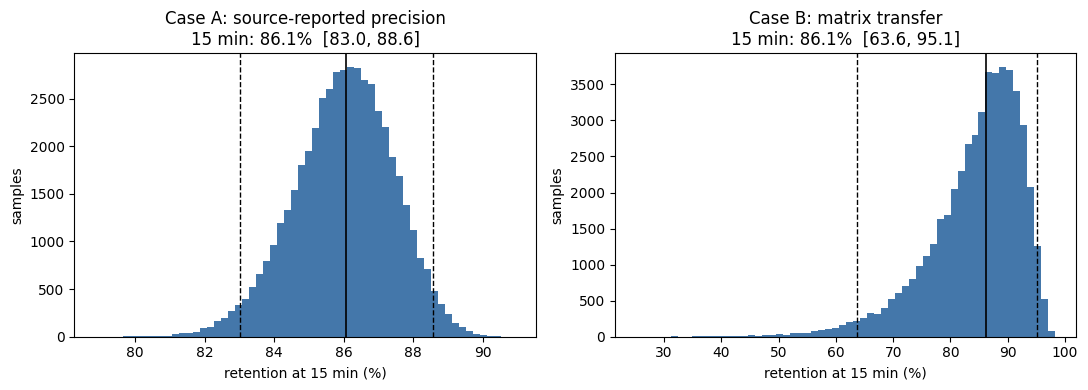

,case,time,mean,sd,median,ci_lo,ci_hi
0,A,10 min,95.37,0.64,95.42,93.98,96.47
1,A,15 min,86.00,1.42,86.07,83.02,88.57
2,A,20 min,76.08,2.14,76.17,71.64,80.05
3,B,10 min,94.69,3.12,95.43,86.63,98.47
4,B,15 min,84.35,8.20,86.13,63.62,95.12
5,B,20 min,73.95,12.25,76.25,44.15,91.30


In [20]:
SEED = 20260917
CV_K_A    = 0.10                 # Case A: 10% CV on k(100 C)
LOGSD_K_B = math.log(3)/1.96     # Case B: 95% interval spans /3 to x3
SD_EA     = 7_400.0              # J/mol, reported standard error on Ea

def draw(n, case, rng):
    sd = CV_K_A if case == "A" else LOGSD_K_B
    return K_SAT * np.exp(rng.normal(0, sd, n)), rng.normal(EA_REF, SD_EA, n)

N_MC = 50_000
summary = []
fig, axes = plt.subplots(1, 2, figsize=(11,4))

for ax, case, label in zip(axes, "AB",
        ["Case A: source-reported precision", "Case B: matrix transfer"]):
    rng = np.random.default_rng(SEED)
    ks, ea = draw(N_MC, case, rng)
    for tt, nm in ((600,"10 min"), (900,"15 min"), (1200,"20 min")):
        r = retention(ks, ea, tt)
        lo, med, hi = np.percentile(r, [2.5, 50, 97.5])
        summary.append(dict(case=case, time=nm, mean=r.mean(), sd=r.std(),
                            median=med, ci_lo=lo, ci_hi=hi))
        if tt == 900:
            ax.hist(r, bins=60, color="#4477aa", edgecolor="none")
            ax.axvline(med, color="k", lw=1.2)
            ax.axvline(lo, color="k", ls="--", lw=1); ax.axvline(hi, color="k", ls="--", lw=1)
            ax.set_title(f"{label}\n15 min: {med:.1f}%  [{lo:.1f}, {hi:.1f}]")
            ax.set_xlabel("retention at 15 min (%)"); ax.set_ylabel("samples")
    print(f"Case {case}: k(100 C) 95% range "
          f"[{np.percentile(ks,2.5):.3e}, {np.percentile(ks,97.5):.3e}] 1/s "
          f"(x{np.percentile(ks,2.5)/K_SAT:.2f} to x{np.percentile(ks,97.5)/K_SAT:.2f})")

plt.tight_layout(); plt.show()
mc = pd.DataFrame(summary)
mc.round(2)

## 8. Sobol variance attribution

Sobol indices divide the variance of the nutrient quantification between the two parameters examined, k(T) and Ea.

Estimated with the Saltelli design; two independent sample matrices A and B, plus hybrid matrices in which one column of A is replaced by B's. A direct one-parameter-at-a-time variance share is printed alongside as a double check; the two should agree closely.

In [21]:
N_SOBOL = 16_384
sob = []
for case in "AB":
    rng = np.random.default_rng(SEED + 1)
    kA, eA = draw(N_SOBOL, case, rng)
    kB, eB = draw(N_SOBOL, case, rng)
    yA, yB = retention(kA, eA), retention(kB, eB)
    yk     = retention(kB, eA)      # A with k replaced by B  -> index for k
    ye     = retention(kA, eB)      # A with Ea replaced by B -> index for Ea
    V = np.var(np.concatenate([yA, yB]))
    sob.append(dict(case=case,
        S1_k  = np.mean(yB*(yk-yA))/V,       S1_Ea = np.mean(yB*(ye-yA))/V,
        ST_k  = np.mean((yA-yk)**2)/(2*V),   ST_Ea = np.mean((yA-ye)**2)/(2*V),
        check_k  = np.var(retention(kA, np.full(N_SOBOL, EA_REF)))/V,
        check_Ea = np.var(retention(np.full(N_SOBOL, K_SAT), eA))/V))
sobol = pd.DataFrame(sob)
sobol.round(3)

,case,S1_k,S1_Ea,ST_k,ST_Ea,check_k,check_Ea
0,A,-0.073,0.130,0.844,0.168,0.837,0.166
1,B,0.861,-0.001,1.002,0.007,0.988,0.005


## 9. Published parameter pairs

Knockaert et al reports a rate constant at a reference temperature of 110 C, not a pre-exponential factor. Back-calculating A from each published (Ea, k_ref) pair and evaluating at 100 C shows where the value adopted in the current study lies relative to the literature.

In [22]:
T_REF_PUB = 383.15            # K, the 110 C reference temperature of the source

pairs = [("olive oil / carrot emulsion", 70_500, 0.099/60),
         ("oil enriched with carrot bc", 75_000, 0.140/60)]

rows=[]
for name, Ea, k_ref in pairs:
    A     = k_ref * math.exp(Ea/(R_GAS*T_REF_PUB))
    k_sat = A * math.exp(-Ea/(R_GAS*T_SAT))
    rows.append(dict(pair=name, Ea_kJ=Ea/1000, A_per_s=A, k_100C=k_sat,
                     ratio_to_adopted=k_sat/K_SAT,
                     ret_15min=retention(k_sat, Ea,  900)[0],
                     ret_20min=retention(k_sat, Ea, 1200)[0]))
rows.append(dict(pair="adopted in this work", Ea_kJ=EA_REF/1000, A_per_s=A_REF,
                 k_100C=K_SAT, ratio_to_adopted=1.0,
                 ret_15min=retention(K_SAT, EA_REF, 900)[0],
                 ret_20min=retention(K_SAT, EA_REF,1200)[0]))
pd.DataFrame(rows).round(4)

,pair,Ea_kJ,A_per_s,k_100C,ratio_to_adopted,ret_15min,ret_20min
0,olive oil / carrot emulsion,70.5,6.746202e+06,0.0009,2.1833,72.1699,55.2718
1,oil enriched with carrot bc,75.0,3.917933e+07,0.0012,2.9728,64.8881,45.1499
2,adopted in this work,70.0,2.630000e+06,0.0004,1.0000,86.0852,76.1826


## 10. Export

Writes exportable files of this analysis


In [23]:
dose_table.round(4).to_csv("uq_dose_table.csv", index=False)
oat.round(2).to_csv("uq_oneatatime.csv", index=False)
mc.round(3).to_csv("uq_montecarlo.csv", index=False)
sobol.round(4).to_csv("uq_sobol.csv", index=False)
pd.DataFrame(rows).round(5).to_csv("uq_published_pairs.csv", index=False)

print("written:")
for f in ["uq_dose_table.csv","uq_oneatatime.csv","uq_montecarlo.csv",
          "uq_sobol.csv","uq_published_pairs.csv"]:
    print("  ", f)

print("\nHeadline numbers for the manuscript")
h = mc[(mc.case=="A") & (mc.time=="15 min")].iloc[0]
print(f"  Case A, 15 min: median {h['median']:.1f}%  95% CI [{h['ci_lo']:.1f}, {h['ci_hi']:.1f}]")
h = mc[(mc.case=="B") & (mc.time=="15 min")].iloc[0]
print(f"  Case B, 15 min: median {h['median']:.1f}%  95% CI [{h['ci_lo']:.1f}, {h['ci_hi']:.1f}]")
s = sobol[sobol.case=="A"].iloc[0]
print(f"  Sobol total (Case A): k(100 C) {s['ST_k']:.2f}, Ea {s['ST_Ea']:.2f}")

written:
   uq_dose_table.csv
   uq_oneatatime.csv
   uq_montecarlo.csv
   uq_sobol.csv
   uq_published_pairs.csv

Headline numbers for the manuscript
  Case A, 15 min: median 86.1%  95% CI [83.0, 88.6]
  Case B, 15 min: median 86.1%  95% CI [63.6, 95.1]
  Sobol total (Case A): k(100 C) 0.84, Ea 0.17
